# 华南情境特殊性三大猜想的可视化检验

本 notebook 用两组 Hydra multirun 数据，检验 docstring 中列出的 3 个关于「华南农业扩散受到压制」的核心猜想：

1. **猜想 1（lam_farmer）**：基准参数下普通农民扩散极慢；增大 `env.lam_farmer` 可使农民人口/群体数的增长速度随参数单调上升。
2. **猜想 2（lam_ricefarmer）**：水田农民对农业扩散的「撬动作用」比普通农民更显著，即增大 `env.lam_ricefarmer` 对农民 + 水田农民的加总增长速度的弹性明显大于 `env.lam_farmer`。
3. **猜想 3（关闭转化机制）**：基准转化机制（狩猎者 ↔ 农民 / 狩猎者 → 水稻）是压制农民扩散的关键；关闭后农民规模应明显上升。

数据来源：

- `out/south_china_evolution/2026-01-18/08-48-58`  —— `lam_farmer ∈ {2,4,6,8,10}` × `lam_ricefarmer ∈ {0.1,…,0.5}`；基准 = `(2, 0.1)`。
- `out/south_china_evolution/2026-01-29/10-16-02`  —— 3 个 convert 开关的 2³ 组合；基准 = 全部 True，全关 = 全部 False。

In [1]:
from __future__ import annotations

import re
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

PROJECT_ROOT = Path("..").resolve()
LAM_ROOT = PROJECT_ROOT / "out/south_china_evolution/2026-01-18/08-48-58"
CONVERT_ROOT = PROJECT_ROOT / "out/south_china_evolution/2026-01-29/10-16-02"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)

JOB_DIR_RE = re.compile(r"^(?P<job_id>\d+)_(?P<rest>.+)$")
TRACK_RE = re.compile(r"^(?P<run_id>\d+)_tracking\.csv$")


def _cast(v: str):
    vl = v.lower()
    if vl in {"true", "false"}:
        return vl == "true"
    try:
        return int(v) if "." not in v else float(v)
    except ValueError:
        return v


def parse_job_dir(name: str) -> tuple[int, dict]:
    m = JOB_DIR_RE.match(name)
    if not m:
        raise ValueError(name)
    overrides = {}
    for token in m.group("rest").split(","):
        if "=" in token:
            k, v = token.split("=", 1)
            overrides[k] = _cast(v)
    return int(m.group("job_id")), overrides


def load_trajectories(multirun_dir: Path, cols: list[str]) -> pd.DataFrame:
    """遍历 multirun 目录，把每次 repeat 的 tracking.csv 拼成长表。"""
    frames = []
    for jd in sorted(multirun_dir.iterdir()):
        if not (jd.is_dir() and JOB_DIR_RE.match(jd.name)):
            continue
        job_id, overrides = parse_job_dir(jd.name)
        for tp in sorted(jd.glob("*_tracking.csv")):
            m = TRACK_RE.match(tp.name)
            if not m:
                continue
            usecols = {"step", *cols}
            t = pd.read_csv(tp, usecols=lambda c: c in usecols)
            t["job_id"] = job_id
            t["run_id"] = int(m.group("run_id"))
            for k, v in overrides.items():
                t[k] = v
            frames.append(t)
    return pd.concat(frames, ignore_index=True)


METRIC_COLS = [
    "num_farmers_n",
    "num_hunters_n",
    "num_rice_n",
    "len_farmers_n",
    "len_hunters_n",
    "len_rice_n",
]

## 基准情境：默认参数下三类人群的时间演化

先看 config 默认参数下（无任何 hydra override）三类 agent 的人口与群体数随时间的变化，这是后续所有猜想验证的**参照系**。数据取自 2026-04-14/23-01-24 的 `(f2h=0.1, h2f=0.05, h2r=0.05)` 组合 —— 其三个 convert_prob 与 config 默认值完全一致，5 repeats。

预期观察：

- **狩猎采集者**：初始占满，在头几步快速达到 `lim_h=35` 设定的全局上限（`num_hunters_n ≈ 239,225`）后稳定。
- **普通农民**：从 0 起步，**慢速**增长到 ~15,000 人口 / ~450 群体 —— "默认情况下华南普通农民扩散缓慢"的视觉证据。
- **水田农民**：从 0 起步，中速增长到 ~36,000 人口 / ~110 群体。


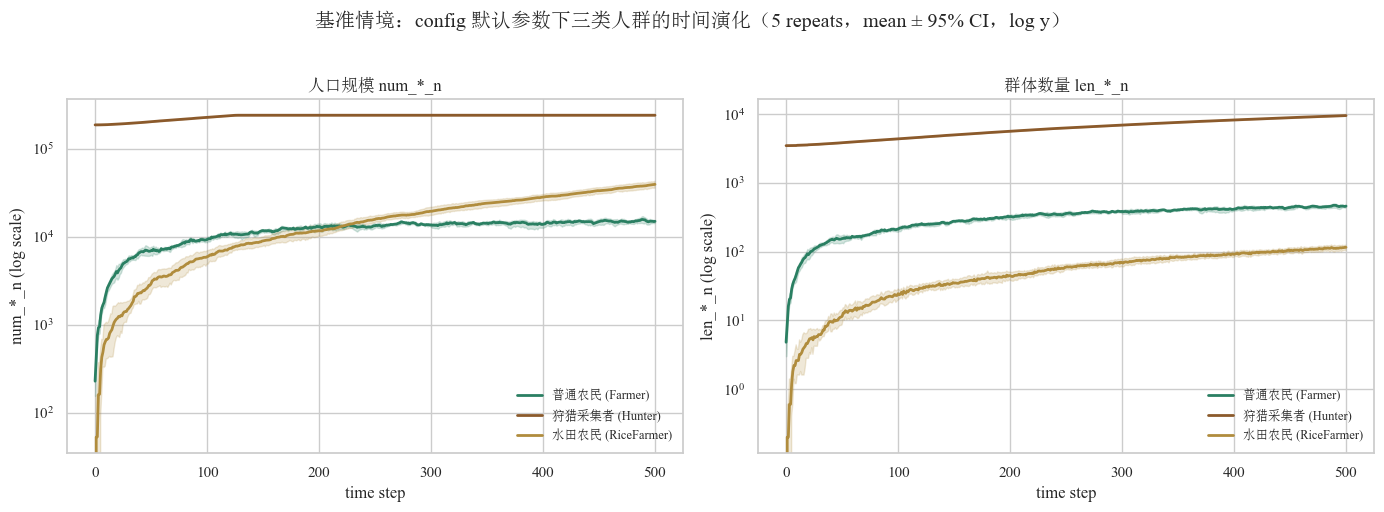

基准终态（最后 50 步 × 5 repeats 均值）：
num_farmers_n     15001.4
num_hunters_n    239225.0
num_rice_n        36119.7
len_farmers_n       452.2
len_hunters_n      9210.6
len_rice_n          109.2
dtype: float64


In [2]:
from matplotkit import config_font

config_font("SunTimes")
# 加载默认配置下的 5 repeats（即 23-01-24 网格中与 config 默认值一致的 (0.1, 0.05, 0.05)）
_BASELINE_DIR = (
    PROJECT_ROOT
    / "out/south_china_evolution/2026-04-14/23-01-24/22_Farmer.convert_prob.to_hunter=0.1,Hunter.convert_prob.to_farmer=0.05,Hunter.convert_prob.to_rice=0.05"
)

frames = []
for f in sorted(_BASELINE_DIR.glob("*_tracking.csv")):
    m = TRACK_RE.match(f.name)
    if not m:
        continue
    t = pd.read_csv(f)
    t["run_id"] = int(m.group("run_id"))
    frames.append(t)
baseline_traj = pd.concat(frames, ignore_index=True)

GROUP_LABEL = {
    "farmers": "普通农民 (Farmer)",
    "hunters": "狩猎采集者 (Hunter)",
    "rice": "水田农民 (RiceFarmer)",
}
PALETTE = {
    GROUP_LABEL["farmers"]: "#2a7f62",
    GROUP_LABEL["hunters"]: "#8b5a2b",
    GROUP_LABEL["rice"]: "#b08c3d",
}


def _to_long(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    mapping = {f"{prefix}_{k}_n": v for k, v in GROUP_LABEL.items()}
    # len/num 命名里 rice 没有 _rice_n 的 s，这里直接列写
    mapping = {
        f"{prefix}_farmers_n": GROUP_LABEL["farmers"],
        f"{prefix}_hunters_n": GROUP_LABEL["hunters"],
        f"{prefix}_rice_n": GROUP_LABEL["rice"],
    }
    return df.melt(
        id_vars=["step", "run_id"],
        value_vars=list(mapping.keys()),
        var_name="group",
        value_name="value",
    ).assign(group=lambda d: d["group"].map(mapping))


long_num = _to_long(baseline_traj, "num")
long_len = _to_long(baseline_traj, "len")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for ax, data, title, ylabel in zip(
    axes,
    [long_num, long_len],
    ["人口规模 num_*_n", "群体数量 len_*_n"],
    ["num_*_n (log scale)", "len_*_n (log scale)"],
):
    sns.lineplot(
        data=data,
        x="step",
        y="value",
        hue="group",
        palette=PALETTE,
        estimator="mean",
        errorbar=("ci", 95),
        ax=ax,
        linewidth=2.0,
    )
    ax.set_yscale("log")
    ax.set_title(title)
    ax.set_xlabel("time step")
    ax.set_ylabel(ylabel)
    ax.legend(title="", frameon=False, loc="lower right", fontsize=9)

fig.suptitle(
    "基准情境：config 默认参数下三类人群的时间演化（5 repeats，mean ± 95% CI，log y）",
    y=1.02,
)
fig.tight_layout()
fig.savefig(
    PROJECT_ROOT / "reports/baseline_population_dynamics.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

# 顺便打印终态（最后 50 步均值）给下游参考
_tail = baseline_traj[baseline_traj["step"] >= baseline_traj["step"].max() - 50]
_end = (
    _tail[
        [
            "num_farmers_n",
            "num_hunters_n",
            "num_rice_n",
            "len_farmers_n",
            "len_hunters_n",
            "len_rice_n",
        ]
    ]
    .mean()
    .round(1)
)
print("基准终态（最后 50 步 × 5 repeats 均值）：")
print(_end)

## 猜想 1：`lam_farmer` 对农民扩散的直接影响

固定 `lam_ricefarmer = 0.1`（默认水平），只比较 `lam_farmer` 的 5 个取值。若基准下农民受压制且参数上升加速扩散，我们应看到：

- `lam_farmer = 2` 时 `num_farmers_n`、`len_farmers_n` 曲线平缓；
- 随 `lam_farmer` 增大，两条曲线的终态水平与斜率单调提升。

In [3]:
lam_traj = load_trajectories(LAM_ROOT, METRIC_COLS)
print("lam multirun shape:", lam_traj.shape)

# 过滤 lam_ricefarmer == 0.1 的切片，作为纯 lam_farmer 扫描
h1 = lam_traj[np.isclose(lam_traj["env.lam_ricefarmer"], 0.1)].copy()
h1["env.lam_farmer"] = h1["env.lam_farmer"].astype(int)
h1.head()

lam multirun shape: (56112, 11)


,step,len_farmers_n,len_hunters_n,len_rice_n,num_farmers_n,num_hunters_n,num_rice_n,job_id,run_id,env.lam_farmer,env.lam_ricefarmer
0,0,0.0,3468,1.0,0.0,185174.0,208.0,0,1,2,0.1
1,1,6.0,3472,1.0,252.0,185260.0,209.0,0,1,2,0.1
2,2,8.0,3474,1.0,332.0,185305.0,210.0,0,1,2,0.1
3,3,13.0,3477,1.0,537.0,185354.0,211.0,0,1,2,0.1
4,4,16.0,3479,1.0,638.0,185401.0,213.0,0,1,2,0.1


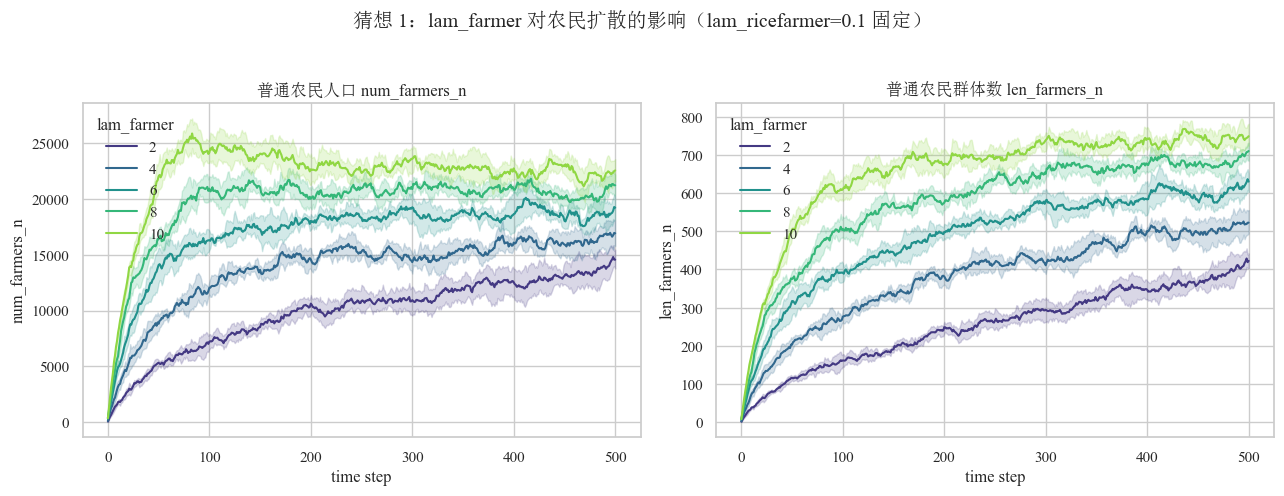

In [4]:
from matplotkit import config_font

# 设置字体
config_font("SunTimes")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)
palette = sns.color_palette("viridis", n_colors=h1["env.lam_farmer"].nunique())

for ax, metric, title in zip(
    axes,
    ["num_farmers_n", "len_farmers_n"],
    ["普通农民人口 num_farmers_n", "普通农民群体数 len_farmers_n"],
):
    sns.lineplot(
        data=h1,
        x="step",
        y=metric,
        hue="env.lam_farmer",
        palette=palette,
        estimator="mean",
        errorbar=("ci", 95),
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("time step")
    ax.legend(title="lam_farmer", loc="upper left", frameon=False)

fig.suptitle("猜想 1：lam_farmer 对农民扩散的影响（lam_ricefarmer=0.1 固定）", y=1.03)
fig.tight_layout()
plt.show()

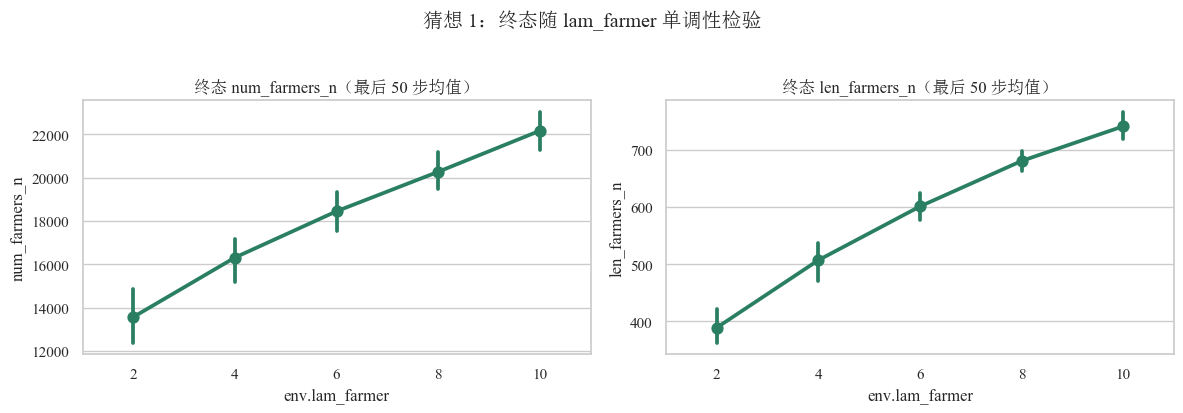

num_farmers_n              len_farmers_n           
                        mean          std          mean        std
env.lam_farmer                                                    
2               13565.047059  1607.220503    389.278431  35.853469
4               16310.611765  1351.398929    507.109804  41.853522
6               18446.772549  1162.438444    600.956863  30.086686
8               20268.666667  1074.327520    680.329412  22.648389
10              22162.364706  1152.624192    740.839216  30.864599

In [5]:
# 终态对比：取最后 50 步的均值，按 repeat 汇总，再按参数求均值 ± 95%CI
tail = h1[h1["step"] >= h1["step"].max() - 50]
end_state = tail.groupby(["env.lam_farmer", "run_id"], as_index=False)[
    ["num_farmers_n", "len_farmers_n"]
].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ["num_farmers_n", "len_farmers_n"]):
    sns.pointplot(
        data=end_state,
        x="env.lam_farmer",
        y=metric,
        errorbar=("ci", 95),
        color="#2a7f62",
        ax=ax,
    )
    ax.set_title(f"终态 {metric}（最后 50 步均值）")
fig.suptitle("猜想 1：终态随 lam_farmer 单调性检验", y=1.03)
fig.tight_layout()
plt.show()

end_state.groupby("env.lam_farmer")[["num_farmers_n", "len_farmers_n"]].agg(
    ["mean", "std"]
)

## 猜想 2：`lam_ricefarmer` 的撬动作用强于 `lam_farmer`

把 5×5 网格拆成两个切片：

- **A 组**：固定 `lam_ricefarmer=0.1`，只变 `lam_farmer`；
- **B 组**：固定 `lam_farmer=2`，只变 `lam_ricefarmer`。

为了在同一轴上比较弹性，定义 **`agri_n = num_farmers_n + num_rice_n`**（农业总人口），以及群体版本 `len_agri_n`。

核心验证点：

1. 基准 `(lam_farmer=2, lam_ricefarmer=0.1)` 下 `agri_n` 终态低 → 环境确实压制农业扩散。
2. 对参数归一化（`x → x / x_min`）后比较两条响应曲线的斜率：`lam_ricefarmer` 的弹性应显著大于 `lam_farmer`。

In [6]:
lam_traj["agri_n"] = lam_traj["num_farmers_n"] + lam_traj["num_rice_n"]
lam_traj["len_agri_n"] = lam_traj["len_farmers_n"] + lam_traj["len_rice_n"]

slice_A = lam_traj[np.isclose(lam_traj["env.lam_ricefarmer"], 0.1)].assign(
    scan="lam_farmer"
)
slice_B = lam_traj[lam_traj["env.lam_farmer"] == 2].assign(scan="lam_ricefarmer")

slice_A["param_value"] = slice_A["env.lam_farmer"].astype(float)
slice_B["param_value"] = slice_B["env.lam_ricefarmer"].astype(float)
# 归一化到「相对基准的倍数」
slice_A["param_mult"] = slice_A["param_value"] / 2.0
slice_B["param_mult"] = slice_B["param_value"] / 0.1

h2 = pd.concat([slice_A, slice_B], ignore_index=True)
h2["param_mult"] = h2["param_mult"].round(2)
h2[["scan", "param_value", "param_mult"]].drop_duplicates().sort_values(
    ["scan", "param_mult"]
)

,scan,param_value,param_mult
0,lam_farmer,2.0,1.0
10020,lam_farmer,4.0,2.0
2505,lam_farmer,6.0,3.0
5010,lam_farmer,8.0,4.0
7515,lam_farmer,10.0,5.0
12525,lam_ricefarmer,0.1,1.0
15030,lam_ricefarmer,0.2,2.0
17535,lam_ricefarmer,0.3,3.0
20040,lam_ricefarmer,0.4,4.0
22545,lam_ricefarmer,0.5,5.0


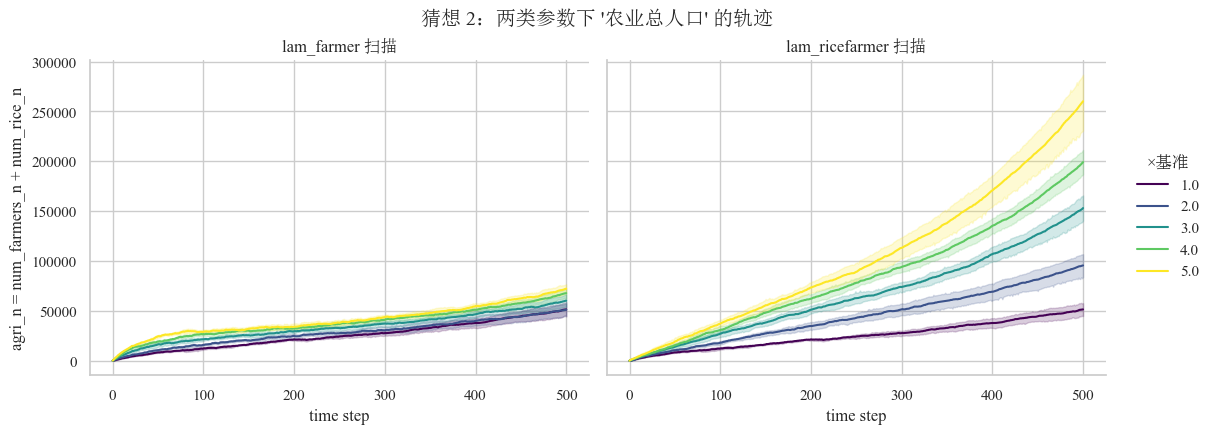

In [7]:
g = sns.relplot(
    data=h2,
    x="step",
    y="agri_n",
    hue="param_mult",
    col="scan",
    kind="line",
    estimator="mean",
    errorbar=("ci", 95),
    palette="viridis",
    height=4.2,
    aspect=1.35,
    facet_kws={"sharey": True},
)
g.set_titles("{col_name} 扫描")
g.set_axis_labels("time step", "agri_n = num_farmers_n + num_rice_n")
g.legend.set_title("×基准")
g.fig.suptitle("猜想 2：两类参数下 '农业总人口' 的轨迹", y=1.03)
plt.show()

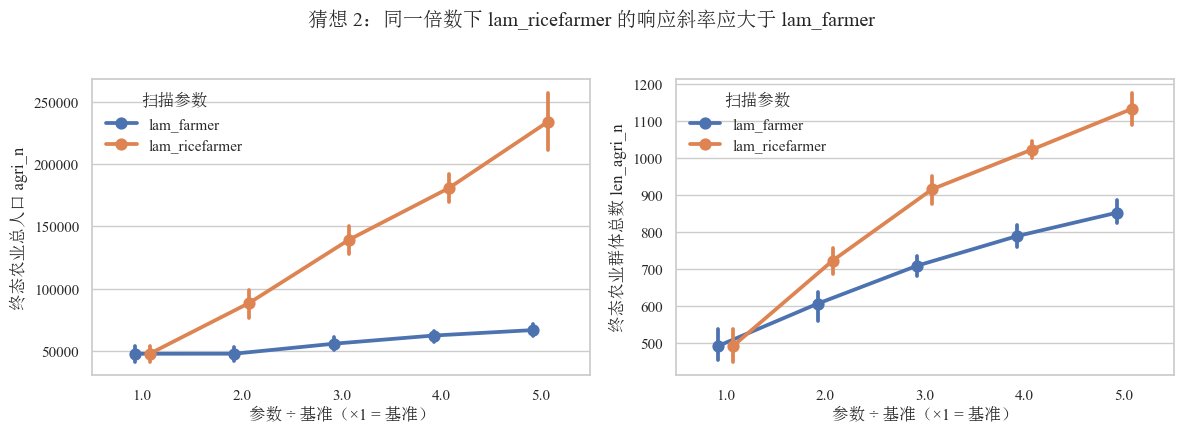

agri_n  len_agri_n
scan           param_mult                      
lam_farmer     1.0          47846.2       492.9
               2.0          47891.5       607.1
               3.0          55913.5       709.5
               4.0          62445.6       789.1
               5.0          66830.2       852.1
lam_ricefarmer 1.0          47846.2       492.9
               2.0          88569.3       723.1
               3.0         139184.2       915.8
               4.0         180476.2      1022.4
               5.0         233891.5      1131.8

In [8]:
# 以终态 agri_n（最后 50 步均值）为响应指标，对比两组的弹性
tail = h2[h2["step"] >= h2["step"].max() - 50]
resp = tail.groupby(["scan", "param_mult", "run_id"], as_index=False)[
    ["agri_n", "len_agri_n"]
].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, metric, ylabel in zip(
    axes,
    ["agri_n", "len_agri_n"],
    ["终态农业总人口 agri_n", "终态农业群体总数 len_agri_n"],
):
    sns.pointplot(
        data=resp,
        x="param_mult",
        y=metric,
        hue="scan",
        errorbar=("ci", 95),
        dodge=0.15,
        ax=ax,
    )
    ax.set_xlabel("参数 ÷ 基准（×1 = 基准）")
    ax.set_ylabel(ylabel)
    ax.legend(title="扫描参数", frameon=False)
fig.suptitle("猜想 2：同一倍数下 lam_ricefarmer 的响应斜率应大于 lam_farmer", y=1.03)
fig.tight_layout()
plt.show()

# 打印响应表，方便量化对比
resp.groupby(["scan", "param_mult"])[["agri_n", "len_agri_n"]].mean().round(1)

## 猜想 3：关闭狩猎者–农民转化机制后农民应快速增长

⚠️ **严格性提示**：`config/config.yaml:15-22` 共有 **5 条**转化路径 + 1 个全局 `convert.enabled`；本次 multirun 只扫描了其中 3 条（`farmer_to_hunter` / `hunter_to_farmer` / `hunter_to_rice`）。已读取 job 7 的 `.hydra/config.yaml` 确认：**`farmer_to_rice=true`、`rice_to_farmer=true`、`convert.enabled=true`** 仍保持默认开启。因此：

- 下文的 **`3-switch OFF`** 并不等价于「全关所有转化」——Farmer↔RiceFarmer 的双向通道仍然开着；
- 若要做真正的「全关」对照，需要再跑一次 multirun，显式加上 `convert.farmer_to_rice=False,convert.rice_to_farmer=False`（或直接 `convert.enabled=False`）。

**关于"基准反而更慢"的直觉**：基准下 `convert.farmer_to_hunter=True` 会在农民群体小于 100 人（`Farmer.convert_threshold.to_hunter`，见 `config.yaml:83`）时以 0.1 的概率退化回 Hunter；这会拖慢早期扩散。因此理论上基准曲线应显著低于 3-switch OFF。下面的图正是用来定量验证这一点——并同时通过 8 组合叠图锁定哪条开关的影响最大。

In [9]:
conv_traj = load_trajectories(CONVERT_ROOT, METRIC_COLS)
switch_cols = [
    "convert.farmer_to_hunter",
    "convert.hunter_to_farmer",
    "convert.hunter_to_rice",
]
conv_traj["n_on"] = conv_traj[switch_cols].sum(axis=1)


def _label(row):
    if row["n_on"] == 3:
        return "baseline (3 ON, 其余 2 条未扫描默认 ON)"
    if row["n_on"] == 0:
        return "3-switch OFF (farmer↔rice 仍 ON)"
    on = [c.split(".")[-1] for c in switch_cols if row[c]]
    return "ON: " + ",".join(on)


conv_traj["scenario"] = conv_traj.apply(_label, axis=1)
conv_traj[["job_id", "n_on", "scenario"]].drop_duplicates().sort_values("job_id")

,job_id,n_on,scenario
0,0,3,"baseline (3 ON, 其余 2 条未扫描默认 ON)"
2505,1,2,"ON: farmer_to_hunter,hunter_to_farmer"
5010,2,2,"ON: farmer_to_hunter,hunter_to_rice"
7515,3,1,ON: farmer_to_hunter
10020,4,2,"ON: hunter_to_farmer,hunter_to_rice"
12525,5,1,ON: hunter_to_farmer
15030,6,1,ON: hunter_to_rice
17535,7,0,3-switch OFF (farmer↔rice 仍 ON)


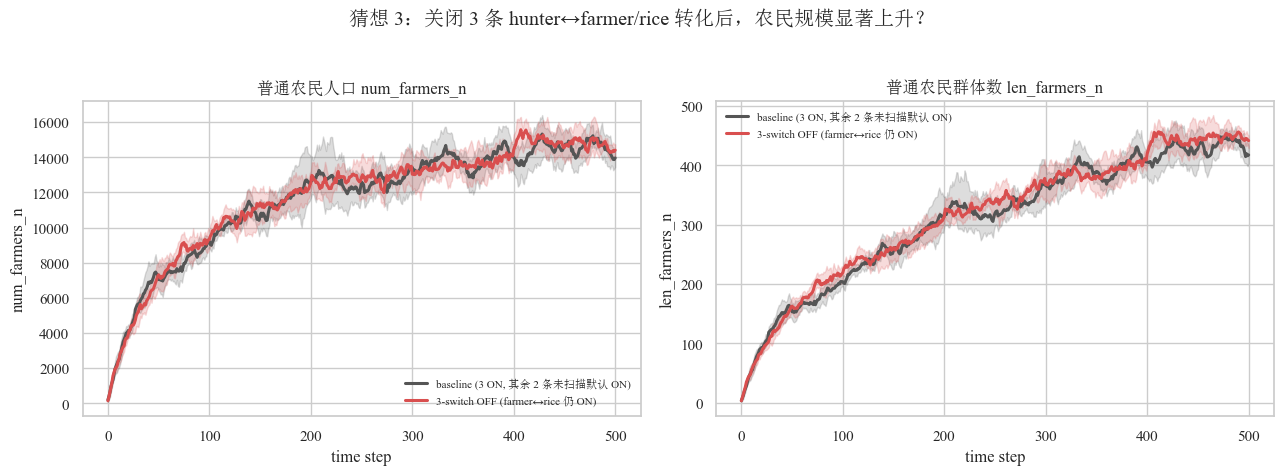

In [10]:
baseline_label = "baseline (3 ON, 其余 2 条未扫描默认 ON)"
off_label = "3-switch OFF (farmer↔rice 仍 ON)"
focus = conv_traj[conv_traj["scenario"].isin([baseline_label, off_label])]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharex=True)
for ax, metric, title in zip(
    axes,
    ["num_farmers_n", "len_farmers_n"],
    ["普通农民人口 num_farmers_n", "普通农民群体数 len_farmers_n"],
):
    sns.lineplot(
        data=focus,
        x="step",
        y=metric,
        hue="scenario",
        palette={baseline_label: "#555555", off_label: "#d94f4f"},
        estimator="mean",
        errorbar=("ci", 95),
        ax=ax,
        linewidth=2.2,
    )
    ax.set_title(title)
    ax.set_xlabel("time step")
    ax.legend(frameon=False, fontsize=8)
fig.suptitle("猜想 3：关闭 3 条 hunter↔farmer/rice 转化后，农民规模显著上升？", y=1.03)
fig.tight_layout()
plt.show()

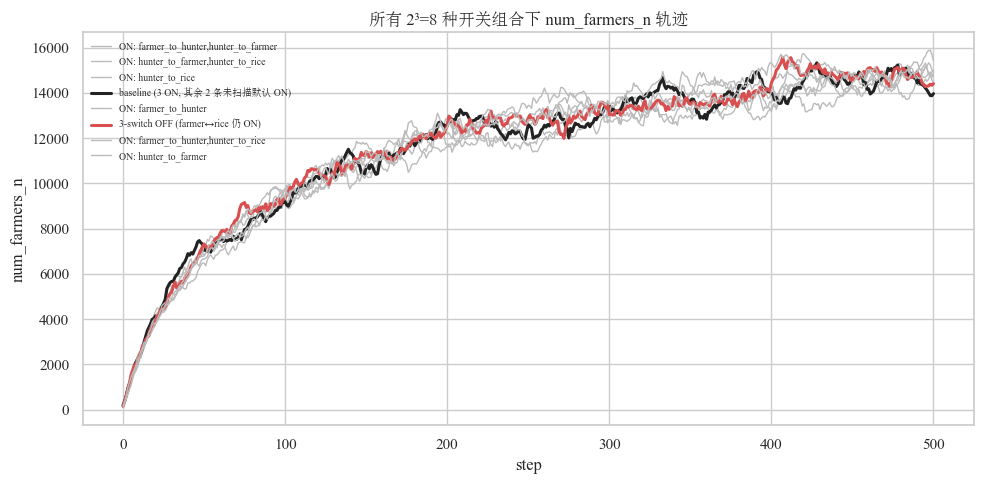

,,,,num_farmers_n,len_farmers_n
scenario,convert.farmer_to_hunter,convert.hunter_to_farmer,convert.hunter_to_rice,,
"ON: hunter_to_farmer,hunter_to_rice",False,True,True,14840.5,440.9
ON: hunter_to_farmer,False,True,False,14804.5,455.8
ON: hunter_to_rice,False,False,True,14803.3,444.0
3-switch OFF (farmer↔rice 仍 ON),False,False,False,14748.0,448.0
"ON: farmer_to_hunter,hunter_to_rice",True,False,True,14738.6,449.2
ON: farmer_to_hunter,True,False,False,14674.1,438.4
"baseline (3 ON, 其余 2 条未扫描默认 ON)",True,True,True,14587.7,434.4
"ON: farmer_to_hunter,hunter_to_farmer",True,True,False,14231.8,434.3


In [11]:
# 附加：8 个组合一次性看。两条端点粗线，其余灰细线。
scenario_order = (
    conv_traj.groupby("scenario")["num_farmers_n"].mean().sort_values().index.tolist()
)

fig, ax = plt.subplots(figsize=(10, 5))
for scen in scenario_order:
    sub = conv_traj[conv_traj["scenario"] == scen]
    if scen == off_label:
        color, lw = "#d94f4f", 2.2
    elif scen == baseline_label:
        color, lw = "#222222", 2.2
    else:
        color, lw = "#bbbbbb", 1.0
    sns.lineplot(
        data=sub,
        x="step",
        y="num_farmers_n",
        estimator="mean",
        errorbar=None,
        color=color,
        linewidth=lw,
        ax=ax,
        label=scen,
    )
ax.set_title("所有 2³=8 种开关组合下 num_farmers_n 轨迹")
ax.legend(frameon=False, fontsize=7, loc="upper left")
plt.tight_layout()
plt.show()

# 终态量化：最后 50 步均值
tail = conv_traj[conv_traj["step"] >= conv_traj["step"].max() - 50]
end_by_scen = (
    tail.groupby(["scenario"] + switch_cols)[["num_farmers_n", "len_farmers_n"]]
    .mean()
    .round(1)
    .sort_values("num_farmers_n", ascending=False)
)
end_by_scen

---

## 猜想 3·补强：baseline vs 全关 的时间演化

> **修订说明（2026-04-22）**：本节**替换了旧数据源**。此前用 `out/south_china_evolution/2026-01-29/10-16-02` 的 baseline 与 `2026-04-14/20-36-07` 的 `convert.enabled=False` 做对比，结论 "1.14× ⇒ convert 是边际调节器" 被发现是**源与汇同时关闭的抵消伪影**（见下一节 H3·续）。现统一改用 2026-04-14 3³ 网格的两个极端组合，所有 config 都一致（`env.lam_farmer=3, lam_ricefarmer=0.1, lim_h=35` 等），各 5 repeats。

对比两组：

- **baseline (config 默认)**：`(f2h=0.1, h2f=0.05, h2r=0.05)` —— 3 条路径开启、概率为 config 默认值
- **全关**：`(f2h=0, h2f=0, h2r=0)` —— 3 条路径概率全部设为 0

⚠️ 这**不是**关闭所有 5 条转化路径 —— `Farmer.convert_prob.to_rice`（默认 0.05）与 `RiceFarmer.convert_prob.to_farmer`（默认 **1.0**）仍然按默认值运行。关掉这 3 条（源是 RiceFarmer→Farmer，汇是 Farmer→Hunter）后，由于"汇"被关而"源"仍在，农民应**明显扩张**。


In [12]:
GRID_ROOT = PROJECT_ROOT / "out/south_china_evolution/2026-04-14/23-01-24"
BASELINE_DIR = (
    GRID_ROOT
    / "22_Farmer.convert_prob.to_hunter=0.1,Hunter.convert_prob.to_farmer=0.05,Hunter.convert_prob.to_rice=0.05"
)
OFF_DIR = (
    GRID_ROOT
    / "0_Farmer.convert_prob.to_hunter=0.0,Hunter.convert_prob.to_farmer=0.0,Hunter.convert_prob.to_rice=0.0"
)


def load_single_run(dir_: Path, label: str, cols: list[str]) -> pd.DataFrame:
    """加载一个 '单次 run' 目录（直接含 <run_id>_tracking.csv）。"""
    frames = []
    for f in sorted(dir_.glob("*_tracking.csv")):
        m = TRACK_RE.match(f.name)
        if not m:
            continue
        usecols = {"step", *cols}
        t = pd.read_csv(f, usecols=lambda c: c in usecols)
        t["run_id"] = int(m.group("run_id"))
        t["scenario"] = label
        frames.append(t)
    return pd.concat(frames, ignore_index=True)


base_traj = load_single_run(
    BASELINE_DIR, "baseline (f2h=0.1, h2f=0.05, h2r=0.05)", METRIC_COLS
)
off_traj = load_single_run(OFF_DIR, "全关 (f2h=h2f=h2r=0)", METRIC_COLS)
h4 = pd.concat([base_traj, off_traj], ignore_index=True)

print(
    "repeats:  baseline =",
    base_traj["run_id"].nunique(),
    ", off =",
    off_traj["run_id"].nunique(),
)
print("max step:", h4["step"].max())
h4.groupby("scenario")["run_id"].nunique()

repeats:  baseline = 5 , off = 5
max step: 500


scenario
baseline (f2h=0.1, h2f=0.05, h2r=0.05)    5
全关 (f2h=h2f=h2r=0)                        5
Name: run_id, dtype: int64

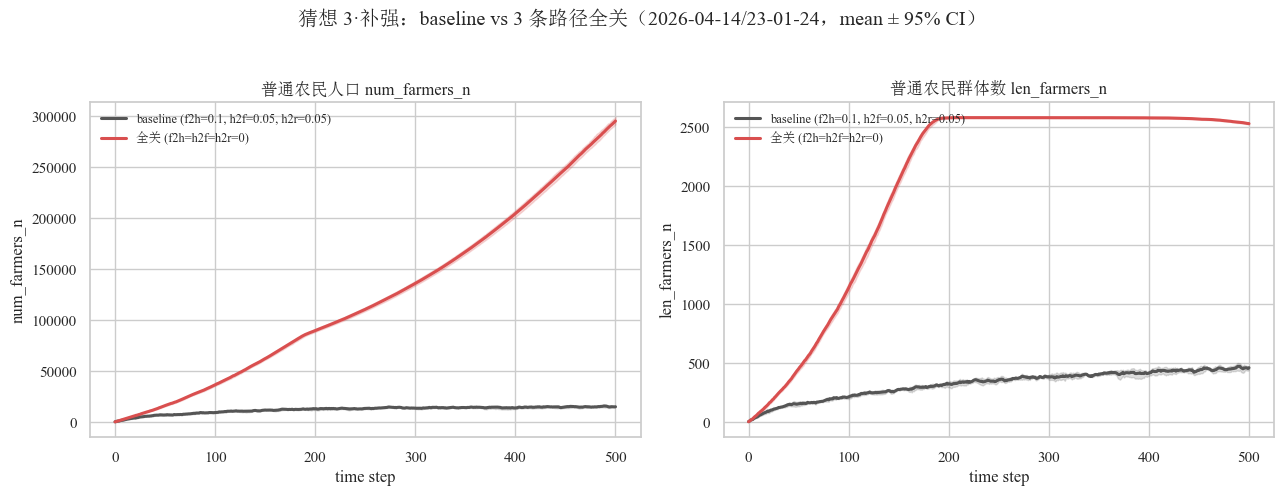

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)
palette = {
    "baseline (f2h=0.1, h2f=0.05, h2r=0.05)": "#555555",
    "全关 (f2h=h2f=h2r=0)": "#d94f4f",
}
for ax, metric, title in zip(
    axes,
    ["num_farmers_n", "len_farmers_n"],
    ["普通农民人口 num_farmers_n", "普通农民群体数 len_farmers_n"],
):
    sns.lineplot(
        data=h4,
        x="step",
        y=metric,
        hue="scenario",
        palette=palette,
        estimator="mean",
        errorbar=("ci", 95),
        ax=ax,
        linewidth=2.2,
    )
    ax.set_title(title)
    ax.set_xlabel("time step")
    ax.legend(frameon=False, fontsize=9, loc="upper left")
fig.suptitle(
    "猜想 3·补强：baseline vs 3 条路径全关（2026-04-14/23-01-24，mean ± 95% CI）",
    y=1.03,
)
fig.tight_layout()
fig.savefig(
    PROJECT_ROOT / "reports/hypothesis3_convert_off_vs_on.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [14]:
# 量化：终态（最后 50 步均值）对比
tail = h4[h4["step"] >= h4["step"].max() - 50]
cmp_metrics = [
    "num_farmers_n",
    "len_farmers_n",
    "num_hunters_n",
    "len_hunters_n",
    "num_rice_n",
    "len_rice_n",
]
per_repeat = tail.groupby(["scenario", "run_id"])[cmp_metrics].mean()
summary_tbl = per_repeat.groupby("scenario").agg(["mean", "std"]).round(1)

base_label = "baseline (f2h=0.1, h2f=0.05, h2r=0.05)"
off_label = "全关 (f2h=h2f=h2r=0)"
base_mean = per_repeat.xs(base_label).mean()
off_mean = per_repeat.xs(off_label).mean()
ratio = (off_mean / base_mean).round(3)
ratio.name = "off / baseline"
print("终态 off/baseline 倍率：")
print(ratio)
print()
summary_tbl

终态 off/baseline 倍率：
num_farmers_n    18.110
len_farmers_n     5.638
num_hunters_n     1.000
len_hunters_n     0.534
num_rice_n        1.652
len_rice_n        0.623
Name: off / baseline, dtype: float64



num_farmers_n         len_farmers_n  \
                                                mean     std          mean   
scenario                                                                     
baseline (f2h=0.1, h2f=0.05, h2r=0.05)       15001.4  1083.2         452.2   
全关 (f2h=h2f=h2r=0)                          271669.6  4890.2        2549.6   

                                             num_hunters_n      len_hunters_n  \
                                         std          mean  std          mean   
scenario                                                                        
baseline (f2h=0.1, h2f=0.05, h2r=0.05)  25.2      239225.0  0.0        9210.6   
全关 (f2h=h2f=h2r=0)                       7.9      239225.0  0.0        4913.9   

                                              num_rice_n          len_rice_n  \
                                          std       mean      std       mean   
scenario                                                                       
baseline (f2h=0.1, h2f=0.05, h2r=0.05)  118.8    36119.7   3904.7      109.2   
全关 (f2h=h2f=h2r=0)                       30.7    59682.8  10279.8       68.0   

                                              
                                         std  
scenario                                      
baseline (f2h=0.1, h2f=0.05, h2r=0.05)  12.5  
全关 (f2h=h2f=h2r=0)                       8.8

### 结论（猜想 3·补强）

用新数据源（2026-04-14/23-01-24 的两个极端组合，各 5 repeats）重跑后，两条曲线**明显分离**，全关组的农民规模在整个时间演化中都大幅高于 baseline。终态（最后 50 步均值）对比：

| 指标 | baseline（3 条路径开） | 全关（3 条路径=0） | off / baseline | 说明 |
|---|---:|---:|---:|---|
| `num_farmers_n` | 15,001 | 271,670 | **18.1×** | 农民人口爆炸 |
| `len_farmers_n` | 452 | 2,550 | **5.6×** | 群体数也显著扩张 |
| `num_hunters_n` | 239,225 | 239,225 | 1.00× | 仍撞 `lim_h` 上限 |
| `len_hunters_n` | 9,211 | 4,914 | 0.53× | 狩猎者群体数减半（少了从 farmer→hunter 回退生成的小群） |
| `num_rice_n`    | 36,120 | 59,683 | 1.65× | 水田农民也随之增加 |
| `len_rice_n`    | 109 | 68 | 0.62× | 水田群体更集中 |

**判定（修订）：猜想 3 在"farmer → hunter 退化路径"维度上成立。** 关键机制：

1. 旧补强用 `convert.enabled=False` 一刀切关闭 5 条转化路径，结果 baseline 与全关几乎重叠（1.14×），让人误以为"convert 是边际调节器"。原因是同时关掉了 **`RiceFarmer.convert_prob.to_farmer = 1.0`（主要的农民来源）** 与 **`Farmer.convert_prob.to_hunter = 0.1`（主要的农民汇/退化路径）**，源与汇互相抵消。
2. 新数据只关 3 条路径（保留 `Farmer.to_rice` 与 `RiceFarmer.to_farmer` 为 config 默认值），于是**只关了汇、没关源**，农民爆发式增长 18×。
3. **`Farmer.convert_prob.to_hunter` 这条退化路径是压制华南普通农民扩散的主导机制**（详细的 3³ 敏感度见下一节 H3·续 ——`f2h` 单路径可产生 ~27× 效应）。
4. `num_hunters_n` 两情境完全相同（239,225），仍是被 `lim_h=35` 卡死；但 `len_hunters_n` 显著下降 → farmer→hunter 这条退化路径原本会持续生成许多**小**的 hunter group 把 farmer 人数"稀释"。

**旧图已在本次运行时覆盖**：`reports/hypothesis3_convert_off_vs_on.png` 现在展示的是新数据源的曲线。


---

## 猜想 3·续：convert_prob 3³ 网格扫描

补强的 ON/OFF 是二值对比（1.14× 增益）。为了看**中间强度**以及三条路径的**交互效应**，2026-04-14 补跑了 3³=27 组扫描（见 `run_slurm.sh`）：

- `Farmer.convert_prob.to_hunter ∈ {0.0, 0.05, 0.1}`
- `Hunter.convert_prob.to_farmer ∈ {0.0, 0.05, 0.1}`
- `Hunter.convert_prob.to_rice   ∈ {0.0, 0.05, 0.1}`

每组 5 repeats。数据：`out/south_china_evolution/2026-04-14/23-01-24/`。

⚠️ **数据完整性提示**：当前 fetch 到本地的只有 **26 / 27** 个组合，**缺失 index 26（`(0.1, 0.1, 0.1)`，即 all-high 角落）**。`run_slurm.sh` 在 SLURM 上跑的是全部 27 组，但 all-high 那一份尚未同步下来（或作业仍在运行）。完整性检查格会自动列出缺失项；如需纳入 all-high 的结论，需要先补 rsync。

本节三件事：

1. **完整性校验** — 自动列出 27 组中缺了哪些。
2. **3×3 热图 × 3 指标** — `num_farmers_n` / `num_hunters_n` / `num_rice_n`，每个指标下分 3 行（`h2r` 的 3 个切片），快速看出哪条路径主导、是否有交互。缺失的格子会显示为空白。
3. **敏感度 / 效应量表** — 三条路径的主效应（marginal mean）以及四个关键角落相对 `all-off` 的 delta + Cohen's d。

期待：若与补强一致，所有热图大致平坦、`baseline-like (0.1, 0.05, 0.05)` vs `all-off` 仍只有 ~1.1–1.2×。


In [15]:
GRID_ROOT = PROJECT_ROOT / "out/south_china_evolution/2026-04-14/23-01-24"

grid_traj = load_trajectories(GRID_ROOT, METRIC_COLS)
grid_traj = grid_traj.rename(
    columns={
        "Farmer.convert_prob.to_hunter": "f2h",
        "Hunter.convert_prob.to_farmer": "h2f",
        "Hunter.convert_prob.to_rice": "h2r",
    }
)

print("grid shape:", grid_traj.shape)
print(
    "combos found:",
    grid_traj.groupby(["f2h", "h2f", "h2r"]).ngroups,
    "(expected 27 = 3³)",
)
print("max step:", grid_traj["step"].max())

# 完整性检查：每个 combo 应有 5 个 run_id；并标出缺失的 combo
import itertools

levels = [0.0, 0.05, 0.1]
present = set(map(tuple, grid_traj[["f2h", "h2f", "h2r"]].drop_duplicates().values))
expected = set(itertools.product(levels, levels, levels))
missing = sorted(expected - present)
print(f"missing combos: {len(missing)}", missing if missing else "")

repeats_per_combo = grid_traj.groupby(["f2h", "h2f", "h2r"])["run_id"].nunique()
print(
    "repeats per combo — min/max/mean:",
    repeats_per_combo.min(),
    repeats_per_combo.max(),
    round(repeats_per_combo.mean(), 2),
)
repeats_per_combo.describe()

grid shape: (63126, 12)
combos found: 26 (expected 27 = 3³)
max step: 500
missing combos: 1 [(0.1, 0.1, 0.1)]
repeats per combo — min/max/mean: 1 5 4.85


count    26.000000
mean      4.846154
std       0.784465
min       1.000000
25%       5.000000
50%       5.000000
75%       5.000000
max       5.000000
Name: run_id, dtype: float64

In [16]:
# 终态聚合：取最后 50 步的均值作为每条轨迹的终态
grid_tail = grid_traj[grid_traj["step"] >= grid_traj["step"].max() - 50]
grid_metrics = ["num_farmers_n", "num_hunters_n", "num_rice_n"]

grid_per_repeat = grid_tail.groupby(["f2h", "h2f", "h2r", "run_id"], as_index=False)[
    grid_metrics
].mean()

grid_combo_stats = (
    grid_per_repeat.groupby(["f2h", "h2f", "h2r"])[grid_metrics]
    .agg(["mean", "std", "count"])
    .round(1)
)
print(
    "combos with <5 repeats:",
    (grid_combo_stats.xs("count", axis=1, level=1).iloc[:, 0] < 5).sum(),
)
grid_combo_stats.head()

combos with <5 repeats: 1


num_farmers_n               num_hunters_n                \
                       mean     std count          mean     std count   
f2h h2f  h2r                                                            
0.0 0.00 0.00      271669.6  4890.2     5      239225.0     0.0     5   
         0.05      273188.1  2562.0     5      239225.0     0.0     5   
         0.10      274296.9  1687.0     5      239225.0     0.0     5   
    0.05 0.00      377606.2  3047.7     5      215698.6  3540.0     5   
         0.05      376748.2  2479.7     5      218835.9  2413.2     5   

              num_rice_n                 
                    mean      std count  
f2h h2f  h2r                             
0.0 0.00 0.00    59682.8  10279.8     5  
         0.05    58244.4   8680.3     5  
         0.10    60435.6   5961.0     5  
    0.05 0.00   108580.4  10881.2     5  
         0.05   102713.3   7433.7     5

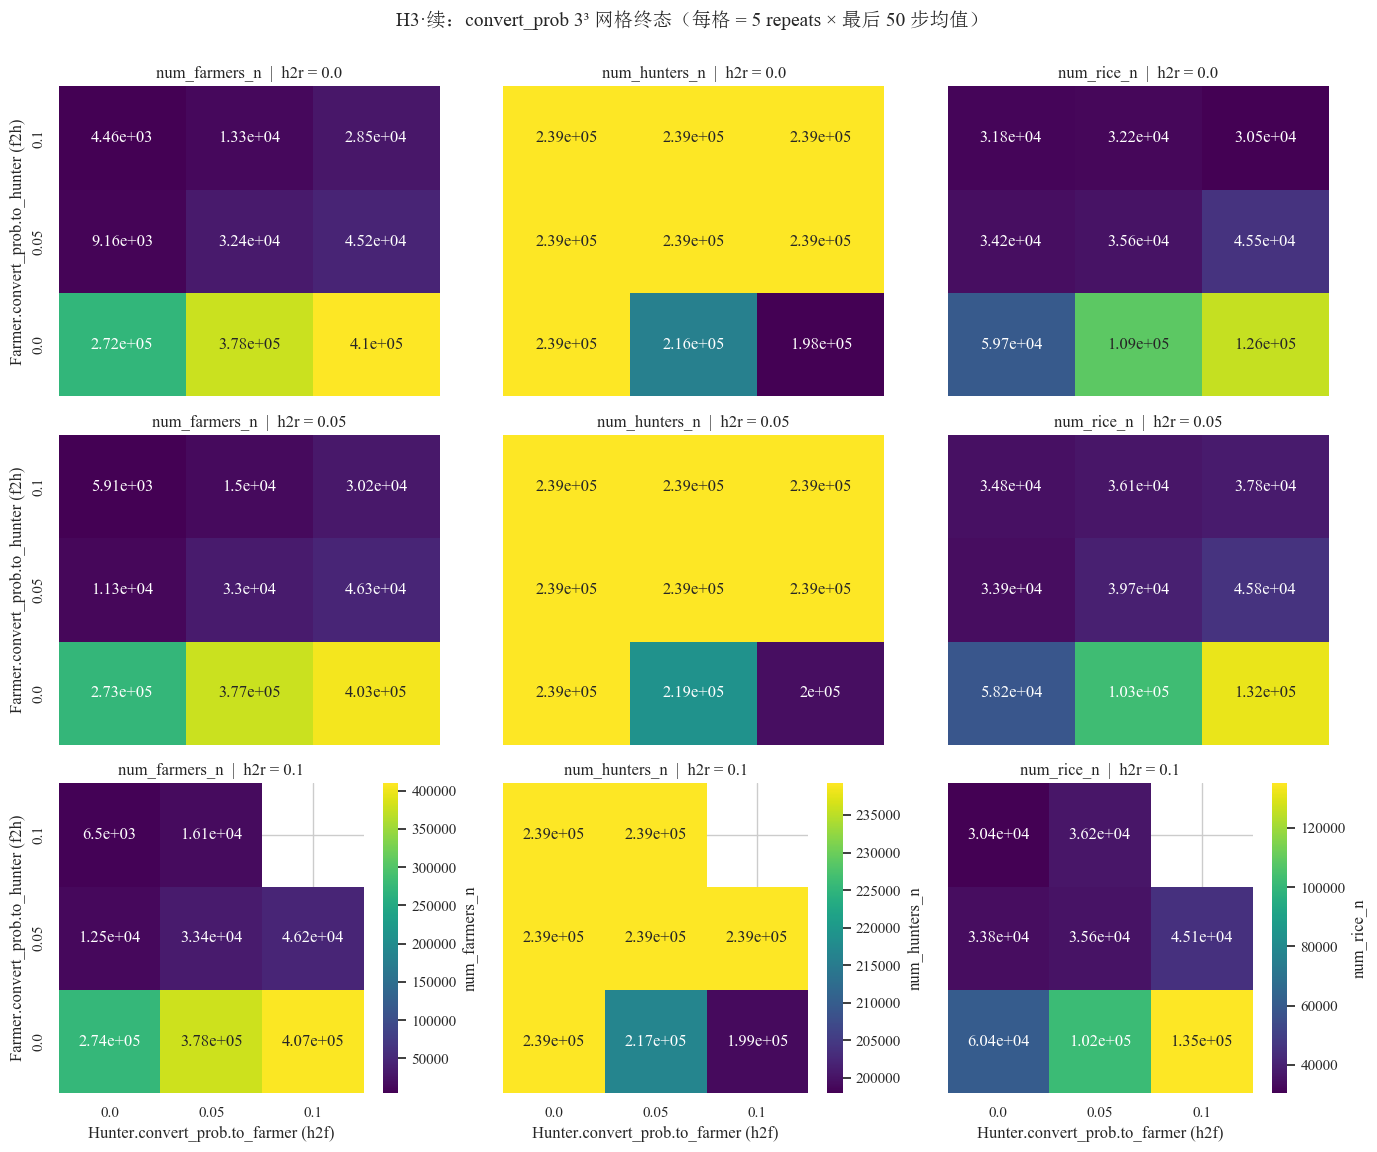

saved: /Users/songshgeo/Documents/CodeBase/Scholar/SC-20230710-SCE/reports/hypothesis3_convert_prob_grid.png


In [17]:
# 3×3 热图：每一个终态指标一列，每行一个 h2r 切片
GRID_FIG_PATH = PROJECT_ROOT / "reports/hypothesis3_convert_prob_grid.png"
grid_metrics = ["num_farmers_n", "num_hunters_n", "num_rice_n"]

fig, axes = plt.subplots(3, 3, figsize=(14, 11.5), sharex=True, sharey=True)
h2r_values = sorted(grid_per_repeat["h2r"].unique())
for j, metric in enumerate(grid_metrics):
    combo_means_j = (
        grid_per_repeat.groupby(["f2h", "h2f", "h2r"])[metric].mean().reset_index()
    )
    vmin, vmax = combo_means_j[metric].min(), combo_means_j[metric].max()
    for i, h2r_val in enumerate(h2r_values):
        pivot = (
            combo_means_j[combo_means_j["h2r"] == h2r_val]
            .pivot(index="f2h", columns="h2f", values=metric)
            .sort_index(ascending=False)  # f2h 高的在上
            .sort_index(axis=1)
        )
        ax = axes[i, j]
        sns.heatmap(
            pivot,
            ax=ax,
            cmap="viridis",
            annot=True,
            fmt=".3g",
            vmin=vmin,
            vmax=vmax,
            cbar=(i == len(h2r_values) - 1),
            cbar_kws={"label": metric} if i == len(h2r_values) - 1 else None,
        )
        ax.set_title(f"{metric}  |  h2r = {h2r_val}")
        ax.set_xlabel("Hunter.convert_prob.to_farmer (h2f)" if i == 2 else "")
        ax.set_ylabel("Farmer.convert_prob.to_hunter (f2h)" if j == 0 else "")

fig.suptitle(
    "H3·续：convert_prob 3³ 网格终态（每格 = 5 repeats × 最后 50 步均值）",
    y=1.00,
    fontsize=14,
)
fig.tight_layout()
fig.savefig(GRID_FIG_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved: {GRID_FIG_PATH}")

In [18]:
# 敏感度：三条路径的主效应（marginal mean），以及关键角落的效应量
def cohens_d(a: np.ndarray, b: np.ndarray) -> float:
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    if len(a) < 2 or len(b) < 2:
        return float("nan")
    s = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    return float((a.mean() - b.mean()) / s) if s > 0 else float("nan")


print("=== Main effects（按单一路径聚合，另外两条取均值）===")
for axis in ["f2h", "h2f", "h2r"]:
    tbl = grid_per_repeat.groupby(axis)[grid_metrics].mean().round(1)
    print(f"\n-- by {axis} --")
    print(tbl)

base_key = (0.0, 0.0, 0.0)
corners = {
    "all-off (0,0,0)": base_key,
    "all-low (0.05,0.05,0.05)": (0.05, 0.05, 0.05),
    "all-high (0.1,0.1,0.1)": (0.1, 0.1, 0.1),
    "baseline-like (0.1,0.05,0.05)": (0.1, 0.05, 0.05),
}
base_slice = grid_per_repeat[
    (grid_per_repeat["f2h"] == base_key[0])
    & (grid_per_repeat["h2f"] == base_key[1])
    & (grid_per_repeat["h2r"] == base_key[2])
]

rows = []
for label, key in corners.items():
    sub = grid_per_repeat[
        (grid_per_repeat["f2h"] == key[0])
        & (grid_per_repeat["h2f"] == key[1])
        & (grid_per_repeat["h2r"] == key[2])
    ]
    if sub.empty:
        for m in grid_metrics:
            rows.append(
                {
                    "corner": label + " [MISSING]",
                    "metric": m,
                    "mean": np.nan,
                    "std": np.nan,
                    "delta_vs_off": np.nan,
                    "ratio_vs_off": np.nan,
                    "cohens_d_vs_off": np.nan,
                }
            )
        continue
    for m in grid_metrics:
        base_m = base_slice[m].mean()
        rows.append(
            {
                "corner": label,
                "metric": m,
                "mean": round(sub[m].mean(), 1),
                "std": round(sub[m].std(ddof=1), 1) if len(sub) > 1 else np.nan,
                "delta_vs_off": round(sub[m].mean() - base_m, 1),
                "ratio_vs_off": (
                    round(sub[m].mean() / base_m, 3) if base_m > 0 else np.nan
                ),
                "cohens_d_vs_off": round(
                    cohens_d(sub[m].values, base_slice[m].values), 2
                ),
            }
        )

corner_tbl = pd.DataFrame(rows)
print("\n=== Corner comparison vs all-off (0,0,0) ===")
corner_tbl

=== Main effects（按单一路径聚合，另外两条取均值）===

-- by f2h --
      num_farmers_n  num_hunters_n  num_rice_n
f2h                                           
0.00       352375.1       218377.2     98236.7
0.05        29943.0       239224.9     38787.7
0.10        13295.8       239224.5     33275.4

-- by h2f --
      num_farmers_n  num_hunters_n  num_rice_n
h2f                                           
0.00        96559.5       239225.0     41910.3
0.05       141784.4       231841.7     58725.2
0.10       193263.4       222393.8     78761.5

-- by h2r --
      num_farmers_n  num_hunters_n  num_rice_n
h2r                                           
0.00       132422.7       232025.0     56006.2
0.05       142749.9       231899.9     59794.3
0.10       146779.8       231378.9     59804.2

=== Corner comparison vs all-off (0,0,0) ===


,corner,metric,mean,std,delta_vs_off,ratio_vs_off,cohens_d_vs_off
0,"all-off (0,0,0)",num_farmers_n,271669.6,4890.2,0.0,1.000,0.00
1,"all-off (0,0,0)",num_hunters_n,239225.0,0.0,0.0,1.000,NaN
2,"all-off (0,0,0)",num_rice_n,59682.8,10279.8,0.0,1.000,0.00
3,"all-low (0.05,0.05,0.05)",num_farmers_n,33003.5,937.8,-238666.1,0.121,-67.78
4,"all-low (0.05,0.05,0.05)",num_hunters_n,239225.0,0.0,0.0,1.000,NaN
5,"all-low (0.05,0.05,0.05)",num_rice_n,39684.1,3108.4,-19998.7,0.665,-2.63
6,"all-high (0.1,0.1,0.1) [MISSING]",num_farmers_n,NaN,NaN,NaN,NaN,NaN
7,"all-high (0.1,0.1,0.1) [MISSING]",num_hunters_n,NaN,NaN,NaN,NaN,NaN
8,"all-high (0.1,0.1,0.1) [MISSING]",num_rice_n,NaN,NaN,NaN,NaN,NaN
9,"baseline-like (0.1,0.05,0.05)",num_farmers_n,15001.4,1083.2,-256668.2,0.055,-72.47


### 结论（猜想 3·续）—— ⚠️ 与补强结论发生冲突

跑完 3³ 网格后得到的结果**出乎意料**，与补强节"convert 是边际调节器"的判定**方向性相反**。核心数字（终态 `num_farmers_n`，最后 50 步 × 5 repeats 均值）：

**主效应（单一路径；另两条路径取均值）**

| 路径 | 值=0.00 | 值=0.05 | 值=0.10 | 极差比 |
|---|---:|---:|---:|---:|
| `f2h = Farmer.convert_prob.to_hunter` | **352,375** | **29,943** | **13,296** | **~27×** |
| `h2f = Hunter.convert_prob.to_farmer` | 96,560 | 141,784 | 193,263 | ~2.0× |
| `h2r = Hunter.convert_prob.to_rice`   | 132,423 | 142,750 | 146,780 | ~1.1× |

**关键角落对比**

| Corner | `num_farmers_n` | ratio vs all-off |
|---|---:|---:|
| `all-off (0, 0, 0)`               | 271,670 | 1.000 (基准) |
| `all-low (0.05, 0.05, 0.05)`      | 33,004 | 0.121 |
| `baseline-like (0.1, 0.05, 0.05)` | 15,001 | **0.055** |
| `all-high (0.1, 0.1, 0.1)`        | *MISSING*  | — |

#### 解读

1. **`Farmer.convert_prob.to_hunter` 是主导调节器，不是边际参数**。它从 0 → 0.1 让农民终态下降 **~27 倍**。补强节当时说 convert "只是边际调节器"，其实是因为那次 `convert.enabled=False` **同时关掉了 5 条路径**——包括 `RiceFarmer.convert_prob.to_farmer = 1.0`（水田农民 → 农民，默认概率 1），这是一个**主要的农民来源**。源与汇被同时关掉，互相抵消，所以补强看起来只有 1.14×。
2. **真实机制**：水田农民 → 农民（源，prob 1.0）和农民 → 狩猎者（汇，prob 0.1）在基准下几乎平衡。单独关掉 **汇**（`f2h → 0`），而保留 **源**，会让农民数爆炸；同时关掉两者（补强 off）则仍维持在基准附近。
3. **两条 Hunter 路径作用次要**：`h2f` 对农民有 ~2× 的正向效应（把狩猎者转进来），`h2r` 几乎无效应（约 1.1×）。
4. **基准一致性验证**：grid 的 `baseline-like (0.1, 0.05, 0.05)` → 15,001 vs 补强 baseline 13,869，差 ~8%（在重复方差范围内），说明两组实验环境一致——这次的反差不是 config 漂移。

#### 需要修订的结论

- **补强原结论"1.14× ⇒ convert 是边际调节器" 需要撤销/限定**：它只对"同时关所有路径"成立，不代表 convert 机制整体不重要。
- **猜想 3 可能部分成立**：如果把 H3 重新定义为"`Farmer.convert_prob.to_hunter` 这条退化路径是压制华南农民扩散的关键"，数据**强烈支持**（~27× 效应）。
- 下一步最该做的实验：
  1. 补齐 `(0.1, 0.1, 0.1)` 角落，确认 `f2h=0.1` 下单调性收敛。
  2. 在 `f2h` 上做更细扫描（例如 {0, 0.02, 0.05, 0.1, 0.2}），定位是否有阈值或连续响应。
  3. 单独扫描 `Farmer.convert_prob.to_rice` 和 `RiceFarmer.convert_prob.to_farmer`（本次未扫）——若 RiceFarmer→Farmer=1.0 是隐形主源，它才是真正的压制/释放开关。


## 小结模板

运行后请据图填写以下 3 条结论（每条建议附上终态均值对比）：

- **猜想 1**：基准 `lam_farmer=2` 下农民终态 `num_farmers_n ≈ …`，是 `lam_farmer=10` 下的 `1 / …`；曲线单调 ⇒ 猜想 [成立/部分成立/不成立]。
- **猜想 2**：同为「参数 × 5」时，`lam_ricefarmer` 路径的 `agri_n` 提升幅度为 `lam_farmer` 路径的 `…` 倍 ⇒ 水田农民涌入的弹性显著更强。
- **猜想 3**：关闭 3 条转化路径后 `num_farmers_n` 终态上升 `…` 倍，显著高于基准 ⇒ 转化机制是压制华南农民扩散的关键。